# Underlying Inflation: Measurement and an Updated Summary Table

This notebook reproduces — updated through the latest available month — the summary
table from **Peneva & Rudd (2020), ["Underlying Inflation: Its Measurement and
Significance"](https://www.federalreserve.gov/econres/notes/feds-notes/underlying-inflation-its-measurement-and-significance-20200918.html),
FEDS Notes, Federal Reserve Board, September 18, 2020.**

The table reports 12 measures of underlying (trend) inflation: two averaging windows
(1998–2007 and 2010–2019) plus the six most recent monthly readings.

| Rows | Content |
|---|---|
| 1–5 | Published series pulled from Bloomberg: core PCE, market-based core PCE, Dallas Fed trimmed-mean PCE, Cleveland Fed median PCE, NY Fed Multivariate Core Trend |
| 6–12 | Models estimated below, following the note's methodology: Stock–Watson UCSV, time-varying AR, two TVP-VARs (overall and market-based core), an expectations-anchored Phillips curve, and two augmented AR inflation-gap models (Michigan and TIPS expectations) |

## Methodology summary

- **Frequency.** Models are estimated at **monthly frequency on the 3-month
  annualized inflation rate** $\pi_t = \big[(P_t/P_{t-3})^4 - 1\big]\cdot 100$ — a rolling
  quarter ending each month, matching the information content and volatility of the
  note's quarterly rate while producing a model estimate every month from a single MCMC
  run. **Exception: the UCSV model uses the month-over-month annualized rate** — see its
  section for why the rolling quarter and a UCSV with time-varying volatility are
  incompatible.
- **Overlap correction.** The rolling quarter makes the transitory shock an
  **MA(2)**: with monthly shocks $\eta$, $\varepsilon_t = \eta_t + \eta_{t-1} + \eta_{t-2}$
  (fixed unit MA weights). The augmented-AR sampler carries this MA component explicitly
  (and its expectations equation keeps the note's MA(1) term); the TV-AR and TVP-VAR lag
  structures absorb it.
- **Estimation.** All Bayesian models use custom Gibbs samplers (numpy/scipy only) built
  on fast banded precision samplers (Chan–Jeliazkov style), the Kim–Shephard–Chib (1998)
  mixture for stochastic volatilities, and Metropolis "level" moves on exact marginal
  likelihoods that protect the trend/noise variance split from the well-known
  zero-variance traps of centered Gibbs samplers. All state samplers were validated
  draw-by-draw against a reference Durbin–Koopman (2002) simulation smoother (kept in
  the utilities cell). The reported estimate is the **posterior median** of each model's
  trend, in annualized percent — the level 12-month inflation is expected to converge
  to, so directly comparable with rows 1–5.
- **Data.** Everything comes from Bloomberg (tickers in the config cell below) and is
  cached to `data/bbg_cache.csv`, so the notebook reruns offline after a first pull on a
  terminal-connected machine.

## Caveats (differences from the note)

- The note's **Nixon-price-control and 9/11 dummy adjustments are not replicated**; the
  stochastic-volatility components absorb outliers, including the COVID-era months.
- The TIPS-based augmented AR model uses the **10-year breakeven** (`USGGBE10`), not the
  6–10-year-forward TIPS rate used in the note; the sample starts in 1999 and early
  breakevens embed liquidity premia.
- Relative import and energy price terms use **fixed nominal shares** (~14% imports,
  ~4% PCE energy), set in the config cell.
- The TVP-VAR uses a **constant orthogonalization matrix** (Clark–Terry style; Primiceri's
  drifting covariance terms are not modeled), and the augmented-AR gap persistence
  $\rho$ and expectations MA term $\psi$ are constant, with $\rho$ restricted to keep
  the gap transitory.
- Trend-shock log-variances carry a data-scaled **lower bound** (spike-at-zero removal)
  and the UCSV vol-of-vol is **fixed at the Stock–Watson (2007) value**; these choices
  are identification safeguards, documented in the model cells.
- **Runtime:** roughly 5–10 minutes at the default draw counts (5,000 iterations for the
  univariate models, 3,000 for the TVP-VARs). Set `MCMC_CONFIG["fast"] = True` for a
  ~2-minute pass with proportionally noisier estimates.

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.linalg as sla
import scipy.sparse as spa
from scipy.stats import truncnorm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------------------------------------------------------- tickers ---
# All raw data comes from Bloomberg. Short names on the left are used
# throughout the notebook; edit the ticker on the right if your terminal
# maps a series differently.
TICKERS = {
    "core_pce":  "PCE CORE Index",   # core PCE price index, level (SA)
    "mb_core":   "PCE MBEX Index",   # market-based core PCE price index, level (starts 1987)
    "dallas_tm": "MPCEPCEY Index",   # Dallas Fed trimmed-mean PCE, 12-month rate
    "clev_med":  "CLEVPCEY Index",   # Cleveland Fed median PCE, YoY
    "mct":       "MCTIMCT Index",    # NY Fed Multivariate Core Trend estimate
                                     # (MCTIC12M is the model's core-12m INPUT)
    "mich_5y":   "CONSP5MD Index",   # U. Michigan median 5-10y inflation expectations
    "tips_be":   "USGGBE10 Index",   # 10y TIPS breakeven, daily -> monthly average
    "urate":     "USURTOT Index",    # unemployment rate
    "nairu":     "CBOPLTUE Index",   # CBO natural rate of unemployment (quarterly)
    "imp_xpet":  "IMP1XPTR Index",   # import prices ex petroleum, index level
    "pce_ene":   "USXIPCEE Index",   # PCE energy price index, level
}
DAILY_TICKERS = {"tips_be"}          # pulled daily, averaged to monthly

START_DATE = "1959-01-01"
DATA_DIR = Path("data")
CACHE_FILE = DATA_DIR / "bbg_cache.csv"
REFRESH = True        # True: try Bloomberg first, fall back to the CSV cache

# Fixed nominal shares used to scale relative price terms (see Fed note):
IMP_SHARE = 0.14      # ~nominal import share of GDP/domestic demand
ENE_SHARE = 0.04      # ~energy share of PCE
# Averaging windows and Phillips-curve sample
AVG_WINDOWS = [("1998-01", "2007-12"), ("2010-01", "2019-12")]
PC_START = "1988-01"

# ------------------------------------------------------------------- MCMC ---
SEED = 20260706
G1_VAR = 2.0    # prior variance of the trend-shock log-variance initial level
SW_VOLVOL = 0.2 ** 2 / 3.0   # SW07 vol-of-vol (0.2/quarter), monthly variance
MCMC_CONFIG = {
    "fast": False,          # True -> quick pass (~4 min total), False -> full precision
    "n_draws": 5000,        # total Gibbs iterations, univariate models
    "n_burn": 1000,
    "var_n_draws": 3000,    # TVP-VARs
    "var_n_burn": 1000,
}
if MCMC_CONFIG["fast"]:
    MCMC_CONFIG.update(n_draws=1500, n_burn=500, var_n_draws=1200, var_n_burn=400)

pd.set_option("display.width", 140)
print(f"Config loaded. MCMC: {MCMC_CONFIG}")

Config loaded. MCMC: {'fast': False, 'n_draws': 5000, 'n_burn': 1000, 'var_n_draws': 3000, 'var_n_burn': 1000}


## Data

One Bloomberg pull for all series (monthly except the 10-year breakeven, which is pulled
daily and averaged to monthly), cached to `data/bbg_cache.csv`. Set `REFRESH = False` in
the config cell to force use of the cache. The prep cell builds the monthly model
dataset: 3-month annualized and 12-month inflation rates, the unemployment gap (CBO
natural rate interpolated from quarterly), and the share-weighted relative import- and
energy-price terms.

In [2]:
def _to_wide(res):
    """Normalise xbbg output to a wide (date x ticker) pandas DataFrame.

    Old xbbg versions return a wide pandas frame with a (ticker, field)
    MultiIndex; xbbg >= 1.x returns a long narwhals table with columns
    ticker/date/field/value. Handle both.
    """
    df = res.to_pandas() if hasattr(res, "to_pandas") else res
    if isinstance(df.columns, pd.MultiIndex):
        df = df.droplevel(-1, axis=1)
    elif {"ticker", "date", "value"}.issubset(df.columns):
        df = df.pivot_table(index="date", columns="ticker", values="value")
    df.index = pd.to_datetime(df.index)
    return df


def fetch_bloomberg():
    """Pull every ticker in TICKERS from Bloomberg; return a monthly frame."""
    from xbbg import blp

    end = pd.Timestamp.today().strftime("%Y-%m-%d")
    monthly_tk = [v for k, v in TICKERS.items() if k not in DAILY_TICKERS]
    daily_tk = [v for k, v in TICKERS.items() if k in DAILY_TICKERS]

    wide_m = _to_wide(blp.bdh(monthly_tk, "PX_LAST", START_DATE, end, Per="M"))
    wide_m.index = wide_m.index.to_period("M")
    wide_m = wide_m.groupby(level=0).last()

    wide_d = _to_wide(blp.bdh(daily_tk, "PX_LAST", START_DATE, end))
    wide_d = wide_d.groupby(wide_d.index.to_period("M")).mean()

    raw = wide_m.join(wide_d, how="outer").sort_index()
    raw = raw.rename(columns={v: k for k, v in TICKERS.items()})
    return raw[list(TICKERS)]


def load_data(refresh=REFRESH):
    """Bloomberg pull with CSV caching so the notebook reruns offline."""
    DATA_DIR.mkdir(exist_ok=True)
    if refresh:
        try:
            raw = fetch_bloomberg()
            raw.to_csv(CACHE_FILE, index_label="month")
            print(f"Pulled {raw.shape[1]} series from Bloomberg through "
                  f"{raw.index.max()}; cached to {CACHE_FILE}")
            return raw
        except Exception as exc:
            print(f"Bloomberg pull failed ({exc!r}); falling back to cache.")
    if CACHE_FILE.exists():
        raw = pd.read_csv(CACHE_FILE, index_col=0)
        raw.index = pd.PeriodIndex(raw.index, freq="M")
        print(f"Loaded cache {CACHE_FILE} (through {raw.index.max()})")
        return raw
    raise RuntimeError("No Bloomberg connection and no cache file; "
                       "run the notebook once on a machine with a terminal.")


raw = load_data()
raw.tail(3)

Pulled 11 series from Bloomberg through 2026-07; cached to data\bbg_cache.csv


ticker,core_pce,mb_core,dallas_tm,clev_med,mct,mich_5y,tips_be,urate,nairu,imp_xpet,pce_ene
date,,,,,,,,,,,
2026-05,130.082,127.02,2.41,2.81557,3.42,3.9,2.46251,4.3,NaN,130.9,165.647
2026-06,NaN,NaN,NaN,NaN,NaN,3.3,2.29810,4.2,4.396,NaN,NaN
2026-07,NaN,NaN,NaN,NaN,NaN,NaN,2.23754,NaN,NaN,NaN,NaN


In [3]:
def ann3m(p):
    """3-month annualized inflation rate of a price index level, in percent."""
    return ((p / p.shift(3)) ** 4 - 1.0) * 100.0


def yoy(p):
    """12-month inflation rate of a price index level, in percent."""
    return (p / p.shift(12) - 1.0) * 100.0


# interior gaps: import prices ex petroleum are quarterly before 1989 and
# skip occasional months (e.g. the late-2025 data disruption); the
# unemployment rate has an isolated missing month. Interpolate inside the
# observed span so 3-month changes and VAR lags stay aligned.
for col in ("imp_xpet", "urate"):
    raw[col] = raw[col].interpolate(limit_area="inside")

mdf = pd.DataFrame(index=raw.index)
# published measures (table rows 1-5)
mdf["yoy_core"] = yoy(raw["core_pce"])
mdf["yoy_mb"] = yoy(raw["mb_core"])
mdf["dallas"] = raw["dallas_tm"]
mdf["clev"] = raw["clev_med"]
mdf["mct"] = raw["mct"]
# model inputs
mdf["pi_core"] = ann3m(raw["core_pce"])    # 3m annualized core PCE inflation
mdf["pi_mb"] = ann3m(raw["mb_core"])       # 3m annualized market-based core
mdf["pi_mm"] = ((raw["core_pce"] / raw["core_pce"].shift(1)) ** 12
                - 1.0) * 100.0             # m/m annualized (UCSV input)
mdf["mich"] = raw["mich_5y"]               # Michigan 5-10y expectations
mdf["tips"] = raw["tips_be"]               # 10y breakeven, monthly average
# unemployment gap: CBO natural rate is quarterly -> linear interpolation
nairu_m = raw["nairu"].interpolate(limit_area="inside").ffill()
mdf["ugap"] = raw["urate"] - nairu_m
# share-weighted relative price terms (3-month changes, vs core PCE inflation)
mdf["rel_imp"] = IMP_SHARE * (ann3m(raw["imp_xpet"]) - mdf["pi_core"])
mdf["rel_ene"] = ENE_SHARE * (ann3m(raw["pce_ene"]) - mdf["pi_core"])

avail = pd.DataFrame({
    "first": mdf.apply(lambda s: s.first_valid_index()),
    "last": mdf.apply(lambda s: s.last_valid_index()),
    "obs": mdf.notna().sum(),
})
print(avail)

            first     last  obs
yoy_core  1960-01  2026-05  797
yoy_mb    1988-01  2026-05  461
dallas    1978-01  2026-05  581
clev      1978-01  2026-05  581
mct       1960-01  2026-05  797
pi_core   1959-04  2026-05  806
pi_mb     1987-04  2026-05  470
pi_mm     1959-02  2026-05  808
mich      1979-02  2026-06  477
tips      1998-08  2026-07  336
ugap      1959-03  2026-06  808
rel_imp   1985-06  2026-05  492
rel_ene   1959-04  2026-05  806


## Shared MCMC machinery

- `tvp_reg_sampler` — banded precision sampler (Chan–Jeliazkov style) for random-walk
  time-varying-parameter regressions: the joint precision of the stacked coefficients is
  block-tridiagonal with diagonal off-blocks, so one O(T) banded Cholesky replaces a
  Kalman forward-backward pass. Used by the TV-AR and (equation-by-equation) the TVP-VARs.
- `sample_trend_ll` / `trend_ll_logml` — tridiagonal draw and exact marginal likelihood
  for the local-level (UCSV) trend. The marginal likelihood powers Metropolis "level"
  moves that let the data pin down the trend-vs-noise variance split directly.
- `sample_sv` — one Gibbs pass for a stochastic-volatility block: Kim–Shephard–Chib
  (1998) 7-component mixture indicators, a tridiagonal precision draw of the log-variance
  path, and (optionally) a conjugate inverse-gamma draw of its random-walk innovation
  variance. Supports a lower bound on the log-variance (spike-at-zero removal).
- `solve_ma3` / `solve_ma3_T` / `solve_ma1` and the `ma*_recover` recursions — fast
  triangular solves used wherever the MA-correlated errors are whitened directly.
- `dk_smoother` — reference Durbin–Koopman (2002) simulation smoother. Not used in
  estimation, but every banded sampler above was validated against it draw-by-draw
  (posterior means and standard deviations agree to Monte-Carlo error).

In [4]:
def band_Lt_solve(cb, z):
    """Solve L' x = z where cb is a lower-banded Cholesky factor
    (scipy.linalg.cholesky_banded output with lower=True). cb's storage is
    exactly BLAS lower-band storage, so dtbsv does the triangular solve."""
    from scipy.linalg import blas
    return blas.dtbsv(cb.shape[0] - 1, cb, z, lower=1, trans=1)


def band_posterior_draw(ab, kvec, rng):
    """Draw from N(K^-1 kvec, K^-1) with K given in lower-banded storage."""
    cb = sla.cholesky_banded(ab, lower=True)
    mean = sla.cho_solve_banded((cb, True), kvec)
    return mean + band_Lt_solve(cb, rng.standard_normal(kvec.size))


def tvp_reg_sampler(y, X, Siginv, qdiag, a1, P1, rng):
    """Draw random-walk TVP-regression coefficients by a banded precision
    sampler (Chan-Jeliazkov 2009 style).

        y_t = X_t beta_t + u_t,  u_t ~ N(0, Sigma_t)
        beta_t = beta_{t-1} + w_t,  w_t ~ N(0, diag(qdiag)),  beta_1 ~ N(a1, P1)

    y: (T, p); X: (T, p, k); Siginv: (T,) [1/sigma^2_t if p == 1] or
    (T, p, p) [Sigma_t^{-1}]. The joint precision of vec(beta) is block-
    tridiagonal with diagonal off-blocks, hence banded with bandwidth k.
    Returns (T, k).
    """
    T, p = y.shape
    k = a1.size
    if Siginv.ndim == 1:
        Xv = X[:, 0, :]
        D = Xv[:, :, None] * Xv[:, None, :] * Siginv[:, None, None]
        kvec = Xv * (Siginv * y[:, 0])[:, None]
    else:
        SX = np.matmul(Siginv, X)                    # (T, p, k), batched BLAS
        D = np.matmul(X.transpose(0, 2, 1), SX)
        kvec = np.einsum("tpk,tp->tk", SX, y)
    P1inv = sla.inv(P1 + 1e-10 * np.eye(k), check_finite=False)
    qinv = 1.0 / qdiag
    D[0] += P1inv
    kvec[0] += P1inv @ a1
    di = np.arange(k)
    D[:-1, di, di] += qinv
    D[1:, di, di] += qinv
    ab = np.zeros((k + 1, T * k))
    for d in range(k):
        ab[d].reshape(T, k)[:, :k - d] = np.diagonal(D, offset=-d,
                                                     axis1=1, axis2=2)
    ab[k].reshape(T, k)[:-1] = -qinv[None, :]
    ab[0] += 1e-10
    return band_posterior_draw(ab, kvec.ravel(), rng).reshape(T, k)


def _local_level_system(yv, dh, dr, a1_mean):
    """Tridiagonal posterior precision (banded storage) and shift for the
    local level model y_t = tau_t + e_t, e_t ~ N(0, dh_t), dtau_t ~
    N(0, dr_t) for t >= 1, tau_1 ~ N(a1_mean, dr_0)."""
    T = yv.size
    ab = np.zeros((2, T))
    ab[0] = 1.0 / dh
    ab[0, 0] += 1.0 / dr[0]
    ab[0, :-1] += 1.0 / dr[1:]
    ab[0, 1:] += 1.0 / dr[1:]
    ab[1, :-1] = -1.0 / dr[1:]
    kvec = yv / dh
    kvec[0] += a1_mean / dr[0]
    return ab, kvec


def sample_trend_ll(yv, dh, dr, a1_mean, rng):
    """Draw the local-level trend path (tridiagonal precision sampler)."""
    ab, kvec = _local_level_system(yv, dh, dr, a1_mean)
    return band_posterior_draw(ab, kvec, rng)


def trend_ll_logml(yv, dh, dr, a1_mean):
    """Marginal log-likelihood of the local level model (trend integrated
    out): log p(y) = log p(y|tau*) + log p(tau*) - log p(tau*|y) at the
    posterior mean tau*. Constants dropped."""
    ab, kvec = _local_level_system(yv, dh, dr, a1_mean)
    cb = sla.cholesky_banded(ab, lower=True)
    mean = sla.cho_solve_banded((cb, True), kvec)
    resid = yv - mean
    lp_y = -0.5 * np.sum(resid * resid / dh + np.log(dh))
    r = np.r_[mean[0] - a1_mean, np.diff(mean)]
    lp_t = -0.5 * np.sum(r * r / dr + np.log(dr))
    return lp_y + lp_t - np.sum(np.log(cb[0]))


def dk_smoother(y, Z, Tm, Qd, R, a1, P1, rng):
    """Durbin-Koopman (2002) simulation smoother (their Algorithm 2).

    NOTE: estimation below uses the much faster banded precision samplers;
    this reference implementation is kept because the banded samplers were
    validated draw-by-draw against it (see the note's verification section).

    Draws a path alpha_{1:n} from p(alpha | y) for the linear Gaussian model
        y_t     = Z_t alpha_t + e_t,          e_t ~ N(0, R_t)
        alpha_t = T  alpha_{t-1} + w_t,       w_t ~ N(0, diag(Qd_t))
        alpha_1 ~ N(a1, P1)

    y  : (n, p) observations; NaN entries are treated as missing
    Z  : (n, p, m) loadings
    Tm : (m, m) constant transition matrix
    Qd : (n, m) diagonal of the state-shock covariance arriving at t (row 0 unused)
    R  : None (no measurement error) | (n,) scalar variances (p = 1) | (n, p, p)
    Returns (n, m) array of sampled states. Used where the measurement error
    is serially correlated and no banded shortcut applies.
    """
    n, p = y.shape
    m = a1.size
    Im = np.eye(m)

    # --- 1. unconditional simulation (alpha+, y+) with zero-mean initial state
    L1 = np.linalg.cholesky(P1 + 1e-10 * Im)
    wplus = np.sqrt(Qd) * rng.standard_normal((n, m))
    if R is None:
        eplus = np.zeros((n, p))
    elif R.ndim == 1:
        eplus = np.sqrt(R)[:, None] * rng.standard_normal((n, p))
    else:
        LR = np.linalg.cholesky(R + 1e-10 * np.eye(p)[None, :, :])
        eplus = np.einsum("tij,tj->ti", LR, rng.standard_normal((n, p)))
    aplus = np.empty((n, m))
    a = L1 @ rng.standard_normal(m)
    for t in range(n):
        if t > 0:
            a = Tm @ a + wplus[t]
        aplus[t] = a
    ystar = y - np.einsum("tij,tj->ti", Z, aplus) - eplus

    at = a1.copy()
    Pt = P1.copy()
    di = np.arange(m)
    if p == 1 and not np.isnan(y).any():
        # --- fast scalar-observation path
        Zv = Z[:, 0, :]
        vF = np.empty(n)
        Ks = np.empty((n, m))
        for t in range(n):
            z = Zv[t]
            Pz = Pt @ z
            F = z @ Pz + (R[t] if R is not None else 0.0) + 1e-12
            v = ystar[t, 0] - z @ at
            K = Pz / F
            vF[t] = v / F
            Ks[t] = K
            at = at + K * v
            Pt = Pt - np.outer(K, Pz)
            if t < n - 1:
                at = Tm @ at
                Pt = Tm @ Pt @ Tm.T
                Pt[di, di] += Qd[t + 1]
        rs = np.empty((n, m))
        r = np.zeros(m)
        for t in range(n - 1, -1, -1):
            u = Tm.T @ r
            r = u + Zv[t] * (vF[t] - Ks[t] @ u)   # L' r + Z F^-1 v
            rs[t] = r
    else:
        # --- general path (multivariate and/or missing observations)
        ZFv = np.zeros((n, m))
        Ls = np.empty((n, m, m))
        for t in range(n):
            obs = ~np.isnan(ystar[t])
            if obs.any():
                Zt = Z[t][obs]
                q = Zt.shape[0]
                v = ystar[t][obs] - Zt @ at
                F = Zt @ Pt @ Zt.T
                if R is not None:
                    F = F + (R[t][np.ix_(obs, obs)] if R.ndim == 3
                             else np.array([[R[t]]]))
                Fi = np.linalg.inv(F + 1e-10 * np.eye(q))
                PZ = Pt @ Zt.T
                K = PZ @ Fi
                ZFv[t] = Zt.T @ (Fi @ v)
                Ls[t] = Tm @ (Im - K @ Zt)
                at = at + K @ v
                Pt = Pt - K @ PZ.T
            else:
                Ls[t] = Tm
            if t < n - 1:
                at = Tm @ at
                Pt = Tm @ Pt @ Tm.T
                Pt[di, di] += Qd[t + 1]
                Pt = 0.5 * (Pt + Pt.T)
        rs = np.empty((n, m))
        r = np.zeros(m)
        for t in range(n - 1, -1, -1):
            r = ZFv[t] + Ls[t].T @ r
            rs[t] = r

    ahat = np.empty((n, m))
    ahat[0] = a1 + P1 @ rs[0]
    for t in range(1, n):
        ahat[t] = Tm @ ahat[t - 1] + Qd[t] * rs[t]
    return ahat + aplus


# Kim-Shephard-Chib (1998) 7-component mixture approximation to log chi^2_1
KSC_P = np.array([0.00730, 0.10556, 0.00002, 0.04395, 0.34001, 0.24566, 0.25750])
KSC_M = np.array([-10.12999, -3.97281, -8.56686, 2.77786, 0.61942, 1.79518, -1.08819])
KSC_V = np.array([5.79596, 2.61369, 5.17950, 0.16735, 0.64009, 0.34023, 1.26261])


def sample_sv(x, h, sig2, rng, h1_mean=None, h1_var=4.0,
              prior_a=10.0, prior_m=0.03, update_scale=True, h_min=-12.0):
    """One Gibbs pass of a stochastic-volatility block (KSC mixture sampler).

    Model: x_t ~ N(0, exp(h_t)), h_t = h_{t-1} + u_t, u_t ~ N(0, sig2),
    h_1 ~ N(h1_mean, h1_var), sig2 ~ IG(prior_a, (prior_a - 1) * prior_m)
    (prior mean of sig2 is prior_m). With update_scale=False the vol-of-vol
    sig2 is held fixed (Stock-Watson 2007 style). h_min truncates the
    log-variance from below: for trend-shock volatilities this removes the
    unbounded density spike at the zero-variance boundary that otherwise
    traps the sampler. Returns updated (h, sig2).
    """
    T = x.size
    ystar = np.log(x * x + 1e-8)
    # mixture indicators (vectorized categorical draw)
    z = ystar[:, None] - h[:, None] - KSC_M[None, :]
    logp = np.log(KSC_P)[None, :] - 0.5 * np.log(KSC_V)[None, :] \
        - 0.5 * z * z / KSC_V[None, :]
    logp -= logp.max(axis=1, keepdims=True)
    prob = np.exp(logp)
    prob /= prob.sum(axis=1, keepdims=True)
    s = (prob.cumsum(axis=1) < rng.random(T)[:, None]).sum(axis=1)
    d = ystar - KSC_M[s]
    v = KSC_V[s]
    # h | s via a tridiagonal precision sampler
    if h1_mean is None:
        h1_mean = np.median(ystar)
    diag = 1.0 / v
    kvec = d / v
    diag[0] += 1.0 / h1_var
    kvec[0] += h1_mean / h1_var
    diag[:-1] += 1.0 / sig2
    diag[1:] += 1.0 / sig2
    ab = np.zeros((2, T))
    ab[0] = diag
    ab[1, :-1] = -1.0 / sig2
    h = np.clip(band_posterior_draw(ab, kvec, rng), h_min, 8.0)
    # sig2 | h (inverse gamma)
    if update_scale:
        a_post = prior_a + 0.5 * (T - 1)
        b_post = prior_m * (prior_a - 1.0) + 0.5 * np.sum(np.diff(h) ** 2)
        sig2 = b_post / rng.gamma(a_post)
    return h, sig2


def draw_ig(a, b, rng):
    """Inverse-gamma(a, b) draw."""
    return b / rng.gamma(a)


def draw_truncnorm(mu, sd, lo, hi, rng):
    return float(truncnorm.rvs((lo - mu) / sd, (hi - mu) / sd,
                               loc=mu, scale=sd, random_state=rng))


# The 3-month annualized rate is a rolling quarter, so its transitory shock is
# eps_t = eta_t + eta_{t-1} + eta_{t-2}: an MA(2) with coefficients fixed at
# (1, 1, 1). In matrix form eps = C eta with C = I + L + L^2 unit lower
# triangular; the recursions below apply C^{-1} and C^{-T}.
def solve_ma3(b):
    z = np.empty_like(b)
    z[0] = b[0]
    if b.size > 1:
        z[1] = b[1] - z[0]
    for t in range(2, b.size):
        z[t] = b[t] - z[t - 1] - z[t - 2]
    return z


def solve_ma3_T(b):
    n = b.size
    z = np.empty_like(b)
    z[-1] = b[-1]
    if n > 1:
        z[-2] = b[-2] - z[-1]
    for t in range(n - 3, -1, -1):
        z[t] = b[t] - z[t + 1] - z[t + 2]
    return z


def solve_ma1(b, psi):
    """z = (I + psi L)^{-1} b."""
    z = np.empty_like(b)
    z[0] = b[0]
    for t in range(1, b.size):
        z[t] = b[t] - psi * z[t - 1]
    return z




print("MCMC utilities defined.")

MCMC utilities defined.


## Model 1 — Stock–Watson (2007) UCSV

$\pi_t = \tau_t + \varepsilon_t$ with $\tau_t$ a driftless random walk; both innovations
carry stochastic volatility with the vol-of-vol fixed at the SW07 value. Underlying
inflation $= \tau_t$.

**Why this model uses the m/m rate.** Unlike the other models, the UCSV is estimated on
month-over-month annualized core PCE inflation rather than the 3-month rate. The rolling
quarter is a low-pass filter: it concentrates the transitory shock's spectral power at
frequency zero, so once the noise volatility is time-varying, a flat trend plus locally
inflated noise volatility fits (nearly) as well as a moving trend — the trend is no
longer identified (verified on simulated data, where the sampler is exact but the trend
collapses). With white m/m noise, trend and noise separate by frequency exactly as in
the original quarterly model. The trend is the same annualized object either way.

In [5]:
def run_ucsv(pi, n_draws, n_burn, rng, label="UCSV", verbose=True):
    """Stock-Watson (2007) UCSV model on month-over-month annualized
    inflation.

    pi_t = tau_t + eps_t with tau_t a driftless random walk; both
    innovations carry stochastic volatility with the vol-of-vol fixed at
    the SW07 value. Estimated on the m/m (not 3-month) rate: the rolling
    quarter is a low-pass filter that concentrates the noise's spectral
    power at frequency zero, so with time-varying noise volatility the
    trend is no longer identified (a flat trend plus adaptive volatility
    fits as well). With white m/m noise, trend and noise separate by
    frequency, as in the original quarterly model. The trend tau is the
    same annualized object, directly comparable across models.

    Sampling: tridiagonal precision draw for tau; KSC mixture for the
    volatility paths; Metropolis level moves for both log-variance levels
    on the exact marginal likelihood (see below).
    """
    y = pi.dropna()
    idx = y.index
    yv = y.values.astype(float)
    T = yv.size

    # initial values: split observed variance between trend and noise.
    # h_anchor / g_anchor pin the *initial* log-variances at a fixed data
    # scale via the initial-condition priors.
    smooth = pd.Series(yv).rolling(24, min_periods=1, center=True).mean().values
    resid0 = yv - smooth
    h_anchor = np.log(max(np.var(resid0), 0.05))
    g_anchor = np.log(max(np.var(np.diff(smooth)), 4e-3))
    h = np.full(T, h_anchor)                # noise log-variance path
    g = np.full(T - 1, g_anchor)            # trend-shock log-variance path
    sig2h = sig2g = SW_VOLVOL               # fixed vol-of-vol, as in SW07
    a1_mean = np.mean(yv[:12])

    keep = n_draws - n_burn
    tau_store = np.empty((keep, T))
    n_scale = 0
    t0 = time.time()
    for it in range(n_draws):
        # 1. level MH moves for BOTH volatility levels on the exact
        # marginal likelihood (trend integrated out): shift the whole
        # log-variance path and accept against the initial-condition
        # prior. The variance levels thus see the data directly; without
        # these moves the centered sampler can drift to a corner where one
        # component absorbs everything (the zero-pileup trap). The third
        # move shifts both levels in opposite directions, travelling along
        # the trend-vs-noise variance ridge.
        dh = np.exp(h)
        dr = np.r_[9.0, np.exp(g)]     # [var(tau_1 prior), var(dtau_t)]
        ll_cur = trend_ll_logml(yv, dh, dr, a1_mean)
        delta = 0.5 * rng.standard_normal()
        dr_p = np.r_[9.0, np.exp(g + delta)]
        ll_p = trend_ll_logml(yv, dh, dr_p, a1_mean)
        la = ll_p - ll_cur - 0.5 * ((g[0] + delta - g_anchor) ** 2
                                    - (g[0] - g_anchor) ** 2) / G1_VAR
        if np.log(rng.random()) < la:
            g, dr, ll_cur = g + delta, dr_p, ll_p
            n_scale += 1
        delta = 0.5 * rng.standard_normal()
        dh_p = np.exp(h + delta)
        ll_p = trend_ll_logml(yv, dh_p, dr, a1_mean)
        la = ll_p - ll_cur - 0.5 * ((h[0] + delta - h_anchor) ** 2
                                    - (h[0] - h_anchor) ** 2) / 4.0
        if np.log(rng.random()) < la:
            h, dh, ll_cur = h + delta, dh_p, ll_p
            n_scale += 1
        delta = 0.5 * rng.standard_normal()
        dr_p = np.r_[9.0, np.exp(g + delta)]
        dh_p = np.exp(h - delta)
        ll_p = trend_ll_logml(yv, dh_p, dr_p, a1_mean)
        la = ll_p - ll_cur \
            - 0.5 * ((g[0] + delta - g_anchor) ** 2
                     - (g[0] - g_anchor) ** 2) / G1_VAR \
            - 0.5 * ((h[0] - delta - h_anchor) ** 2
                     - (h[0] - h_anchor) ** 2) / 4.0
        if np.log(rng.random()) < la:
            g, h, dr, dh, ll_cur = g + delta, h - delta, dr_p, dh_p, ll_p
            n_scale += 1

        # 2. trend | volatilities (tridiagonal precision draw)
        tau = sample_trend_ll(yv, dh, dr, a1_mean, rng)

        # 3. volatility paths (KSC mixture; vol-of-vol fixed)
        h, sig2h = sample_sv(yv - tau, h, sig2h, rng, h1_mean=h_anchor,
                             update_scale=False)
        g, sig2g = sample_sv(np.diff(tau), g, sig2g, rng, h1_mean=g_anchor,
                             h1_var=G1_VAR, update_scale=False,
                             h_min=g_anchor - 2.5)
        if it >= n_burn:
            tau_store[it - n_burn] = tau
        if verbose and (it + 1) % 1000 == 0:
            print(f"  {label}: iter {it + 1}/{n_draws} "
                  f"({time.time() - t0:.0f}s)", flush=True)
    trend = pd.Series(np.median(tau_store, axis=0), index=idx, name=label)
    return {"trend": trend, "scale_accept": n_scale / (3.0 * n_draws),
            "bands": pd.DataFrame(
                np.percentile(tau_store, [16, 84], axis=0).T,
                index=idx, columns=["p16", "p84"])}


# --- run ---
t0 = time.time()
res_ucsv = run_ucsv(mdf["pi_mm"], MCMC_CONFIG["n_draws"],
                    MCMC_CONFIG["n_burn"], np.random.default_rng([SEED, 1]))
print(f"UCSV done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_ucsv['trend'].iloc[-1]:.2f}%; volatility-level MH acceptance = "
      f"{res_ucsv['scale_accept']:.0%}")

  UCSV: iter 1000/5000 (6s)


  UCSV: iter 2000/5000 (11s)


  UCSV: iter 3000/5000 (16s)


  UCSV: iter 4000/5000 (21s)


  UCSV: iter 5000/5000 (27s)


UCSV done in 27s; latest trend = 3.02%; volatility-level MH acceptance = 46%


## Model 2 — Time-varying AR(2)

$\pi_t = \mu_t + \phi_{1,t}\pi_{t-1} + \phi_{2,t}\pi_{t-2} + e_t$ with random-walk
coefficients and SV errors (two lags, per the note's footnote 8). Underlying inflation is
the local mean $\mu_t/(1-\phi_{1,t}-\phi_{2,t})$; draws with roots at or inside the unit
circle (or a denominator below 0.02) are set aside and the share is reported.

In [6]:
def run_tvar(pi, n_draws, n_burn, rng, label="TV-AR", verbose=True):
    """Time-varying AR(2) with drifting coefficients and SV errors.

    pi_t = mu_t + phi1_t pi_{t-1} + phi2_t pi_{t-2} + e_t, e_t ~ N(0, exp(h_t));
    (mu, phi1, phi2) follow independent random walks. Local mean (trend)
    = mu_t / (1 - phi1_t - phi2_t), computed per retained draw with unstable
    or near-unit-root draws set aside (share reported). The AR lags absorb
    the MA(2) serial correlation induced by the overlapping 3-month window.
    """
    y0 = pi.dropna()
    yv = y0.values.astype(float)
    Y = yv[2:]
    X = np.column_stack([np.ones(Y.size), yv[1:-1], yv[:-2]])
    idx = y0.index[2:]
    T, k = X.shape

    # OLS on the first 10 years for the initial-state prior
    ntr = min(120, T // 3)
    Xtr, Ytr = X[:ntr], Y[:ntr]
    XtX = Xtr.T @ Xtr + 1e-6 * np.eye(k)
    b_ols = np.linalg.solve(XtX, Xtr.T @ Ytr)
    s2 = np.sum((Ytr - Xtr @ b_ols) ** 2) / max(ntr - k, 1)
    V_ols = s2 * np.linalg.inv(XtX)

    a1 = b_ols
    P1 = 4.0 * V_ols + 1e-8 * np.eye(k)
    Xp = X[:, None, :]
    mq = np.array([2.5e-3, 1e-4, 1e-4])   # prior means of RW variances
    q = mq.copy()
    h_anchor = np.log(max(s2, 0.05))
    h = np.full(T, h_anchor)
    sig2h = 0.03

    keep = n_draws - n_burn
    trend_store = np.full((keep, T), np.nan)
    n_rej = 0
    t0 = time.time()
    for it in range(n_draws):
        beta = tvp_reg_sampler(Y[:, None], Xp, np.exp(-h), q, a1, P1, rng)
        e = Y - np.einsum("tk,tk->t", X, beta)
        h, sig2h = sample_sv(e, h, sig2h, rng, h1_mean=h_anchor)
        db = np.diff(beta, axis=0)
        for j in range(k):
            q[j] = draw_ig(10.0 + 0.5 * (T - 1),
                           9.0 * mq[j] + 0.5 * np.sum(db[:, j] ** 2), rng)
        if it >= n_burn:
            mu, p1c, p2c = beta[:, 0], beta[:, 1], beta[:, 2]
            den = 1.0 - p1c - p2c
            stable = (p1c + p2c < 0.98) & (p2c - p1c < 2.0) \
                & (np.abs(p2c) < 1.0) & (den > 0.02)
            n_rej += int((~stable).sum())
            trend_store[it - n_burn] = np.where(stable, mu / den, np.nan)
        if verbose and (it + 1) % 1000 == 0:
            print(f"  {label}: iter {it + 1}/{n_draws} "
                  f"({time.time() - t0:.0f}s)", flush=True)
    rej_rate = n_rej / (keep * T)
    trend = pd.Series(np.nanmedian(trend_store, axis=0), index=idx, name=label)
    return {"trend": trend, "reject_rate": rej_rate}


# --- run ---
t0 = time.time()
res_tvar = run_tvar(mdf["pi_core"], MCMC_CONFIG["n_draws"],
                    MCMC_CONFIG["n_burn"], np.random.default_rng([SEED, 2]))
print(f"TV-AR done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_tvar['trend'].iloc[-1]:.2f}%; unstable-draw share = "
      f"{res_tvar['reject_rate']:.1%}")

  TV-AR: iter 1000/5000 (3s)


  TV-AR: iter 2000/5000 (6s)


  TV-AR: iter 3000/5000 (9s)


  TV-AR: iter 4000/5000 (12s)


  TV-AR: iter 5000/5000 (16s)


TV-AR done in 16s; latest trend = 3.62%; unstable-draw share = 0.0%


## Models 3 & 4 — TVP-VAR with stochastic volatility

Four variables per the note's specification (labor-cost term omitted, energy term added):
share-weighted relative import price change, share-weighted relative energy price change,
core PCE inflation (overall or market-based), and the unemployment gap. Two lags,
random-walk intercepts and coefficients, SV innovations (Clark–Terry 2010 style with a
constant orthogonalization). Coefficients are drawn equation by equation on the
triangularized system (Carriero–Clark–Marcellino style), with Primiceri-style priors on
the coefficient drift tied to training-sample OLS uncertainty — loose priors let the
coefficients interpolate the data and the volatilities collapse. Underlying inflation is
the inflation element of the local long-run mean
$\bar z_t = (I - B_{1,t} - B_{2,t})^{-1}\mu_t$, computed on every 2nd retained draw with
explosive draws discarded (share reported). The first five years serve as a training
sample for the priors and are dropped from estimation.

In [7]:
def run_tvpvar(df, n_draws, n_burn, rng, label="TVP-VAR",
               inf_pos=2, n_lag=2, n_train=60, verbose=True):
    """TVP-VAR with stochastic volatility (Clark-Terry 2010 style).

    Variables (per the Fed note, lines 4-5 of their spec): share-weighted
    relative import price change, share-weighted relative energy price
    change, core inflation, unemployment gap. Time-varying intercepts and
    coefficients follow random walks; innovations have SV with a constant
    lower-triangular orthogonalization A (a simplification of Primiceri's
    drifting A_t, documented in the intro). Coefficients are drawn equation
    by equation on the triangularized system (Carriero-Clark-Marcellino
    2019 style Gibbs blocks). Underlying inflation is the inflation element
    of the local long-run mean zbar_t = (I - B1_t - B2_t)^{-1} mu_t, with
    explosive draws discarded. The first n_train months serve as an OLS
    training sample for the priors and are dropped from estimation.
    """
    data = df.dropna()
    D = data.values.astype(float)
    nv = D.shape[1]
    Yall = D[n_lag:]
    Xall = np.column_stack([np.ones(Yall.shape[0])]
                           + [D[n_lag - j - 1:-j - 1 or None] for j in range(n_lag)])
    # per-equation training OLS for priors
    ntr = min(n_train, Yall.shape[0] // 4)
    kx = Xall.shape[1]                     # 1 + nv * n_lag regressors per equation
    a1_eq, P1_eq, s2_eq, mq_eq = [], [], [], []
    XtX = Xall[:ntr].T @ Xall[:ntr] + 1e-6 * np.eye(kx)
    XtXi = sla.inv(XtX)
    for i in range(nv):
        bi = XtXi @ (Xall[:ntr].T @ Yall[:ntr, i])
        s2 = np.sum((Yall[:ntr, i] - Xall[:ntr] @ bi) ** 2) / max(ntr - kx, 1)
        a1_eq.append(bi)
        P1_eq.append(4.0 * s2 * XtXi)
        s2_eq.append(max(s2, 1e-4))
        # Primiceri-style random-walk-variance prior means: coefficient
        # drift scaled to OLS uncertainty (k_Q = 0.03/month); the intercept
        # gets a floor so the long-run mean can drift over decades. Tight
        # dof (prior_a below) prevent the TVP overfitting spiral where
        # coefficients interpolate the data and the SV collapses.
        vd = s2 * np.diag(XtXi)
        mq_eq.append(np.r_[max(0.03 ** 2 * vd[0], 5e-4),
                           np.maximum(0.03 ** 2 * vd[1:], 1e-7)])

    # estimation sample = everything after the training window
    Y = Yall[ntr:]
    Xrow = Xall[ntr:]
    Xp = Xrow[:, None, :]
    idx = data.index[n_lag + ntr:]
    T = Y.shape[0]

    mq = np.array(mq_eq)                        # (nv, kx) RW-variance prior means
    prior_a = 20.0                              # IG dof for the q's
    q = mq.copy()
    A = np.eye(nv)
    h = np.tile(np.log(s2_eq), (T, 1))
    sig2h = np.full(nv, 0.03)
    Beta = np.tile(np.array(a1_eq)[None], (T, 1, 1))     # (T, nv, kx)
    U = Y - np.einsum("tk,tik->ti", Xrow, Beta)

    keep = n_draws - n_burn
    lr_thin = 2                     # long-run mean computed every 2nd kept draw
    n_lr = (keep + lr_thin - 1) // lr_thin
    trend_store = np.full((n_lr, T), np.nan)
    n_rej = 0
    Inv = np.eye(nv)
    t0 = time.time()
    for it in range(n_draws):
        # 1. TVP coefficients, equation by equation on the triangular system:
        #    row i of A(y_t - X_t beta_t) = e_t gives, conditional on the
        #    other equations, z_t = x_t' beta_{i,t} + e_{i,t}.
        for i in range(nv):
            z = Y[:, i] + (U @ A[i] - U[:, i])
            Beta[:, i, :] = tvp_reg_sampler(
                z[:, None], Xp, np.exp(-h[:, i]), q[i],
                a1_eq[i], P1_eq[i], rng)
            U[:, i] = Y[:, i] - np.einsum("tk,tk->t", Xrow, Beta[:, i, :])
        # 2. orthogonalization A (constant, row by row)
        for i in range(1, nv):
            Xi = -U[:, :i]
            w = np.exp(-h[:, i])
            Kp = Xi.T @ (Xi * w[:, None]) + 0.1 * np.eye(i)
            # einsum, not gemv: MKL's transposed dgemv is pathologically
            # slow on some Windows builds
            kv = np.einsum("t,ti->i", w * U[:, i], Xi)
            L = sla.cholesky(Kp, lower=True, check_finite=False)
            mean = sla.cho_solve((L, True), kv, check_finite=False)
            A[i, :i] = mean + sla.solve_triangular(
                L.T, rng.standard_normal(i), lower=False, check_finite=False)
        # 3. stochastic volatilities of orthogonalized shocks
        E = U @ A.T
        for i in range(nv):
            h[:, i], sig2h[i] = sample_sv(E[:, i], h[:, i], sig2h[i], rng,
                                          h1_mean=np.log(s2_eq[i]))
        # 4. random-walk variances of the coefficients
        ssq = np.sum(np.diff(Beta, axis=0) ** 2, axis=0)   # (nv, kx)
        q = ((prior_a - 1.0) * mq + 0.5 * ssq) \
            / rng.gamma(prior_a + 0.5 * (T - 1), size=(nv, kx))
        # 5. local long-run mean per retained (thinned) draw
        if it >= n_burn and (it - n_burn) % lr_thin == 0:
            MU = Beta[:, :, 0]
            B1 = Beta[:, :, 1:1 + nv]
            B2 = Beta[:, :, 1 + nv:1 + 2 * nv]
            comp = np.zeros((T, 2 * nv, 2 * nv))
            comp[:, :nv, :nv] = B1
            comp[:, :nv, nv:] = B2
            comp[:, nv:, :nv] = Inv
            ok = np.abs(np.linalg.eigvals(comp)).max(axis=1) < 0.995
            n_rej += int((~ok).sum())
            M = Inv[None] - B1 - B2
            M = np.where(ok[:, None, None], M, Inv[None])
            zbar = np.linalg.solve(M, MU[..., None])[..., 0]
            trend_store[(it - n_burn) // lr_thin] = \
                np.where(ok, zbar[:, inf_pos], np.nan)
        if verbose and (it + 1) % 500 == 0:
            print(f"  {label}: iter {it + 1}/{n_draws} "
                  f"({time.time() - t0:.0f}s)", flush=True)
    rej_rate = n_rej / (n_lr * T)
    trend = pd.Series(np.nanmedian(trend_store, axis=0), index=idx, name=label)
    return {"trend": trend, "reject_rate": rej_rate}


def var_frame(pi_col):
    """4-variable system for the TVP-VAR, built around the given inflation measure."""
    return pd.DataFrame({
        "rel_imp": IMP_SHARE * (ann3m(raw["imp_xpet"]) - mdf[pi_col]),
        "rel_ene": ENE_SHARE * (ann3m(raw["pce_ene"]) - mdf[pi_col]),
        "pi": mdf[pi_col],
        "ugap": mdf["ugap"],
    })


# --- run ---
t0 = time.time()
res_var_core = run_tvpvar(var_frame("pi_core"), MCMC_CONFIG["var_n_draws"],
                          MCMC_CONFIG["var_n_burn"],
                          np.random.default_rng([SEED, 3]), label="TVP-VAR core")
print(f"TVP-VAR (core) done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_var_core['trend'].iloc[-1]:.2f}%; explosive-draw share = "
      f"{res_var_core['reject_rate']:.1%}")

t0 = time.time()
res_var_mb = run_tvpvar(var_frame("pi_mb"), MCMC_CONFIG["var_n_draws"],
                        MCMC_CONFIG["var_n_burn"],
                        np.random.default_rng([SEED, 4]), label="TVP-VAR mb")
print(f"TVP-VAR (market-based) done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_var_mb['trend'].iloc[-1]:.2f}%; explosive-draw share = "
      f"{res_var_mb['reject_rate']:.1%}")

  TVP-VAR core: iter 500/3000 (8s)


  TVP-VAR core: iter 1000/3000 (15s)


  TVP-VAR core: iter 1500/3000 (25s)


  TVP-VAR core: iter 2000/3000 (36s)


  TVP-VAR core: iter 2500/3000 (45s)


...

  TVP-VAR mb: iter 1500/3000 (24s)


  TVP-VAR mb: iter 2000/3000 (34s)


  TVP-VAR mb: iter 2500/3000 (44s)


  TVP-VAR mb: iter 3000/3000 (54s)


TVP-VAR (market-based) done in 54s; latest trend = 3.31%; explosive-draw share = 7.0%


## Model 5 — Expectations-anchored Phillips curve (Michigan)

The note's equation (1): $\pi_t = (1-\phi)(\hat\pi^e_t + \lambda) + \phi\pi_{t-1} +
\beta\tilde U_t + \gamma X_t + \varepsilon_t$, estimated by OLS from 1988 with the unit
restriction on long-run expectations imposed. Underlying inflation
$= \hat\pi^e_t + \hat\lambda$ with $\hat\lambda = \hat c/(1-\hat\phi)$: the level
inflation settles at with a zero unemployment gap and zero relative import-price change,
holding expectations at their current value.

In [8]:
def run_pc(mdf, expec_col="mich", start=PC_START, label="Phillips curve"):
    """Expectations-anchored Phillips curve (note's equation (1)).

    pi_t = (1 - phi)(pihat_e_t + lambda) + phi pi_{t-1} + beta ugap_t
           + gamma rel_imp_t + eps_t.
    The unit restriction on expectations is imposed by running OLS on
    (pi_t - pihat_e_t) = c + phi (pi_{t-1} - pihat_e_t) + beta ugap_t
    + gamma rel_imp_t, sample 1988->present. Underlying inflation is the
    level inflation converges to with a zero gap, zero relative import
    price change and expectations held at their current value:
    pihat_e_t + lambda_hat, lambda_hat = c / (1 - phi_hat).
    """
    df = pd.DataFrame({
        "pi": mdf["pi_core"],
        "pil": mdf["pi_core"].shift(1),
        "e": mdf[expec_col],
        "ugap": mdf["ugap"],
        "rimp": mdf["rel_imp"],
    }).loc[pd.Period(start, freq="M"):].dropna()
    yv = (df["pi"] - df["e"]).values
    X = np.column_stack([np.ones(len(df)), (df["pil"] - df["e"]).values,
                         df["ugap"].values, df["rimp"].values])
    b, *_ = np.linalg.lstsq(X, yv, rcond=None)
    resid = yv - X @ b
    s2 = resid @ resid / (len(df) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    c, phi, beta_u, gamma = b
    lam = c / (1.0 - phi)
    coefs = pd.DataFrame({"coef": b, "se": se},
                         index=["const", "phi (lagged inflation)",
                                "beta (u gap)", "gamma (rel import)"])
    trend = (mdf[expec_col] + lam).loc[df.index.min():].rename(label)
    return {"trend": trend, "coefs": coefs, "lam": lam, "phi": phi}


# --- run ---
res_pc = run_pc(mdf)
print(res_pc["coefs"].round(3))
print(f"lambda_hat = {res_pc['lam']:.2f} -> latest underlying inflation = "
      f"{res_pc['trend'].dropna().iloc[-1]:.2f}%")

                         coef     se
const                  -0.100  0.035
phi (lagged inflation)  0.841  0.026
beta (u gap)           -0.024  0.017
gamma (rel import)      0.090  0.053
lambda_hat = -0.63 -> latest underlying inflation = 2.67%


## Models 6 & 7 — Augmented AR inflation gap (Michigan / TIPS)

Chan–Clark–Koop-style model per the note: the deviation of inflation from a random-walk
trend $\pi^*_t$ follows an AR(1), and long-run expectations provide a second, noisy
reading on the trend through $\hat\pi^e_t = d_{0,t} + d_{1,t}\pi^*_t + \nu_t +
\psi\nu_{t-1}$ with time-varying $d_0, d_1$ and SV everywhere. The inflation-gap error
carries the MA(2) overlap correction; the expectations anchor is what keeps the trend
identified at the 3-month frequency. All states are drawn jointly by one banded O(T)
sampler (the exact measurement equations keep the precision banded), with tight
random-walk priors on $(d_0, d_1)$ and a transitory-gap restriction on $\rho$
(both documented in the sampler docstrings). Simplifications vs. the paper: constant
$\rho$ and $\psi$. The TIPS variant swaps in the 10-year breakeven from 1999 (see
caveats).

In [9]:
def _augar_precision(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean):
    """Banded posterior precision (ab), shift (kv) and pistar positions (ip)
    of the interleaved latent vector
        z = (eta_{-1}, eta_0, nu_0, pistar_1, eta_1, nu_1, pistar_2, ...)
    for the augmented AR model. Both measurement equations hold exactly;
    they are imposed as soft constraints with negligible noise (variance
    1e-8), which keeps the precision banded with bandwidth 6. The
    pre-sample inflation gap is set to zero (boundary approximation, decays
    at rate rho).
    """
    T = pv.size
    P = 3                                  # presample block (eta_-1, eta_0, nu_0)
    N = 3 * T + P
    DEL = 1e-8
    eh, ek, eg = np.exp(h), np.exp(kk), np.exp(g)
    ab = np.zeros((7, N))
    kv = np.zeros(N)
    ip = P + 3 * np.arange(T)              # pistar_t positions; eta_t = ip+1, nu_t = ip+2
    # --- priors ---
    ab[0, 0] += 1.0 / eh[0]
    ab[0, 1] += 1.0 / eh[0]
    ab[0, 2] += 1.0 / ek[0]
    ab[0, ip + 1] += 1.0 / eh
    ab[0, ip + 2] += 1.0 / ek
    ab[0, ip[0]] += 1.0 / 9.0              # pistar_1 ~ N(a1_mean, 9)
    kv[ip[0]] += a1_mean / 9.0
    ab[0, ip[1:]] += 1.0 / eg              # random-walk prior on pistar
    ab[0, ip[:-1]] += 1.0 / eg
    ab[3, ip[:-1]] -= 1.0 / eg
    # --- expectations equation, t = 1..T:
    # r_t = (e_t - d0_t) - [psi nu_{t-1} + d1_t pistar_t + nu_t]
    bC = ip - 1
    offC = np.array([0, 1, 3])
    wC = np.column_stack([np.full(T, psi), d1, np.ones(T)])
    cC = (ev - d0) / DEL
    for i in range(3):
        kv[bC + offC[i]] += wC[:, i] * cC
        for j in range(i + 1):
            ab[offC[i] - offC[j], bC + offC[j]] += wC[:, i] * wC[:, j] / DEL
    # --- inflation-gap equation, t = 1 (gap_0 = 0):
    # r_1 = pi_1 - [eta_{-1} + eta_0 + pistar_1 + eta_1]
    idx1 = np.array([0, 1, ip[0], ip[0] + 1])
    for i in range(4):
        kv[idx1[i]] += pv[0] / DEL
        for j in range(i + 1):
            ab[idx1[i] - idx1[j], idx1[j]] += 1.0 / DEL
    # --- inflation-gap equation, t = 2..T:
    # r_t = (pi_t - rho pi_{t-1})
    #       - [eta_{t-2} - rho pistar_{t-1} + eta_{t-1} + pistar_t + eta_t]
    bB = ip[1:] - 5                        # column of eta_{t-2}
    offB = np.array([0, 2, 3, 5, 6])
    Tm1n = T - 1
    wB = np.column_stack([np.ones(Tm1n), np.full(Tm1n, -rho),
                          np.ones(Tm1n), np.ones(Tm1n), np.ones(Tm1n)])
    cB = (pv[1:] - rho * pv[:-1]) / DEL
    for i in range(5):
        kv[bB + offB[i]] += wB[:, i] * cB
        for j in range(i + 1):
            ab[offB[i] - offB[j], bB + offB[j]] += wB[:, i] * wB[:, j] / DEL
    return ab, kv, ip


def sample_augar_states(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean, rng):
    """Joint draw of (pistar, eta, nu) plus the pre-sample values
    (eta_-1, eta_0, nu_0), from the banded posterior."""
    ab, kv, ip = _augar_precision(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean)
    z = band_posterior_draw(ab, kv, rng)
    return z[ip], z[ip + 1], z[ip + 2], z[:3]


def augar_logml(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean):
    """Marginal log-likelihood of the data given (d, rho, psi, vols), with
    all latent states integrated out analytically:
    log p(y) = log p(y|z*) + log p(z*) - log p(z*|y) at the posterior mean
    z*. The soft-constraint terms at z* are O(1e-8) and constants are
    dropped."""
    ab, kv, ip = _augar_precision(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean)
    cb = sla.cholesky_banded(ab, lower=True)
    z = sla.cho_solve_banded((cb, True), kv)
    pist, et, nv_ = z[ip], z[ip + 1], z[ip + 2]
    dpi = np.diff(pist)
    lp = -0.5 * ((pist[0] - a1_mean) ** 2 / 9.0
                 + np.sum(dpi * dpi * np.exp(-g) + g))
    lp += -0.5 * (np.sum(et * et * np.exp(-h) + h)
                  + (z[0] ** 2 + z[1] ** 2) * np.exp(-h[0]) + 2.0 * h[0])
    lp += -0.5 * (np.sum(nv_ * nv_ * np.exp(-kk) + kk)
                  + z[2] ** 2 * np.exp(-kk[0]) + kk[0])
    return lp - np.sum(np.log(cb[0]))


def sample_dblock(ev, pistar, psi, kk, q_d, m0, rng):
    """Draw (d0, d1, nu) for the expectations equation
        e_t = d0_t + d1_t pistar_t + nu_t + psi nu_{t-1}
    with random-walk priors on (d0, d1) and SV variance exp(kk) on nu.

    The equation holds exactly given the latent variables, so d0 is
    eliminated (it enters with a unit coefficient) and
    z = (nu_0, d1_1, nu_1, d1_2, nu_2, ...) is drawn from its Gaussian
    posterior, whose precision is banded with bandwidth 4: the d0
    random-walk prior links only variables within two periods.
    Priors: d0_1 ~ N(m0, 4), d1_1 ~ N(1, 0.25), nu_0 ~ N(0, exp(kk_1)).
    """
    T = ev.size
    q0, q1 = q_d
    N = 2 * T + 1
    ab = np.zeros((5, N))
    kv = np.zeros(N)
    ek = np.exp(kk)
    # nu ~ N(0, exp(kk)); presample nu_0 uses the first period's variance
    ab[0, 0] += 1.0 / ek[0]
    ab[0, 2::2] += 1.0 / ek
    # d1 random walk, d1_1 ~ N(1, 0.25)
    ab[0, 1] += 4.0
    kv[1] += 4.0
    ab[0, 1:N - 2:2] += 1.0 / q1
    ab[0, 3::2] += 1.0 / q1
    ab[2, 1:N - 2:2] -= 1.0 / q1
    # d0_1 ~ N(m0, 4): residual r_1 = (e_1 - m0) - [psi nu_0 + p*_1 d1_1 + nu_1]
    w1 = np.array([psi, pistar[0], 1.0])
    c1 = ev[0] - m0
    for i in range(3):
        kv[i] += w1[i] * c1 / 4.0
        for j in range(i + 1):
            ab[i - j, j] += w1[i] * w1[j] / 4.0
    # Delta d0_t ~ N(0, q0) for t = 2..T:
    # r_t = de_t - [-psi nu_{t-2} - p*_{t-1} d1_{t-1} + (psi-1) nu_{t-1}
    #               + p*_t d1_t + nu_t]
    base = 2 * np.arange(2, T + 1) - 4          # column index of nu_{t-2}
    W = np.column_stack([
        np.full(T - 1, -psi),                    # nu_{t-2}
        -pistar[:-1],                            # d1_{t-1}
        np.full(T - 1, psi - 1.0),               # nu_{t-1}
        pistar[1:],                              # d1_t
        np.ones(T - 1),                          # nu_t
    ])
    cvec = np.diff(ev)
    for i in range(5):
        kv[base + i] += W[:, i] * cvec / q0
        for j in range(i + 1):
            ab[i - j, base + j] += W[:, i] * W[:, j] / q0
    ab[0] += 1e-10
    z = band_posterior_draw(ab, kv, rng)
    nu_pre = z[0]
    d1 = z[1::2]
    nu = z[2::2]
    d0 = ev - d1 * pistar - nu - psi * np.r_[nu_pre, nu[:-1]]
    return d0, d1, nu


def run_aug_ar(pi, expec, n_draws, n_burn, rng, label="AugAR", verbose=True):
    """Augmented AR inflation-gap model with a survey/market expectations link
    (Chan-Clark-Koop 2018 style, per the note's description).

        pi_t - pistar_t = rho (pi_{t-1} - pistar_{t-1}) + eps_t
        pistar_t        = pistar_{t-1} + w_t,  w_t ~ N(0, exp(g_t))
        pihat_e_t       = d0_t + d1_t pistar_t + nu_t + psi nu_{t-1}

    eps_t = eta_t + eta_{t-1} + eta_{t-2} (MA(2), overlapping 3-month window),
    eta and nu carry stochastic volatility; d0_t, d1_t are random walks.
    Simplifications vs. the paper (documented): rho and psi are constant
    (rho drawn by GLS with the MA-correlated errors, psi by random-walk
    Metropolis on the marginal MA(1) likelihood); the gap AR has one lag;
    the pre-sample inflation gap is set to zero (a boundary approximation
    whose effect dies out at rate rho).

    Sampling of (pistar, eta, nu) exploits the degeneracy of the two
    measurement equations: given eta (augmented with its two pre-sample
    values), the trend is pinned down as pistar = pi - S eta with
    S = (I - rho L)^{-1} C, and nu = nu0 + Mnu eta follows. Only eta is
    sampled; its posterior precision is dense but small (one Cholesky).
    """
    frame = pd.DataFrame({"pi": pi, "pil": pi.shift(1), "e": expec})
    valid = frame.notna().all(axis=1).values
    if not valid.any():
        raise ValueError(f"{label}: no overlapping sample")
    lastT = np.where(valid)[0].max()
    gaps = np.where(~valid[:lastT + 1])[0]
    start = gaps.max() + 1 if gaps.size else 0
    frame = frame.iloc[start:lastT + 1]        # final contiguous block
    idx = frame.index
    pv = frame["pi"].values.astype(float)
    ev = frame["e"].values.astype(float)
    T = pv.size

    # initial values; the SV blocks are anchored at these fixed data-scale
    # levels to avoid the zero-pileup trap (see the UCSV cell)
    pistar = pd.Series(pv).rolling(24, min_periods=1, center=True).mean().values
    rho, psi = 0.7, 0.3
    d1 = np.ones(T)
    d0 = np.full(T, ev.mean() - pv.mean())
    h_anchor = np.log(max(np.var(pv - pistar) / 3.0, 0.05))       # eta
    g_anchor = np.log(max(np.var(np.diff(pistar)), 4e-3))         # trend shock
    k_anchor = np.log(max(np.var(ev) / 4.0, 0.01))                # nu
    h = np.full(T, h_anchor)
    g = np.full(T - 1, g_anchor)
    kk = np.full(T, k_anchor)
    sig2h, sig2g, sig2k = 0.03, 0.03, 0.03
    # tight RW-variance priors on (d0, d1): with both free, the expectations
    # equation could fit any path without the trend moving
    mq_d = np.array([1e-4, 2e-5])
    q_d = mq_d.copy()

    a1_mean = np.mean(pv[:12])
    m0 = ev[:24].mean() - pv[:24].mean()

    keep = n_draws - n_burn
    star_store = np.empty((keep, T))
    n_acc = 0
    n_scale = 0
    t0 = time.time()
    for it in range(n_draws):
        # Block order makes this a valid partially collapsed Gibbs sampler:
        # blocks 0-2 integrate latent states out (or condition only on the
        # previous sweep's pistar), and every marginalized variable is
        # refreshed (blocks 3-4) before the volatility steps condition on it.

        # 0. level MH for the trend-shock volatility on the exact marginal
        # likelihood (see the UCSV cell)
        delta = 0.5 * rng.standard_normal()
        la = augar_logml(pv, ev, d0, d1, rho, psi, h, g + delta, kk, a1_mean) \
            - augar_logml(pv, ev, d0, d1, rho, psi, h, g, kk, a1_mean) \
            - 0.5 * ((g[0] + delta - g_anchor) ** 2
                     - (g[0] - g_anchor) ** 2) / G1_VAR
        if np.log(rng.random()) < la:
            g = g + delta
            n_scale += 1

        # 1. rho | pistar, vols -- GLS with MA(2)-correlated errors. The
        # prior N(0.5, 0.2^2), truncated to (-0.9, 0.9), keeps the gap
        # transitory: with a loose prior, trend variation leaks into a
        # near-unit-root gap and the trend goes flat.
        gap = pv - pistar
        x, yr = gap[:-1], gap[1:]
        Dinv = np.exp(-h[1:])
        Oix = solve_ma3_T(Dinv * solve_ma3(x))
        prec = x @ Oix + 1.0 / 0.04
        mean = (yr @ Oix + 0.5 / 0.04) / prec
        rho = draw_truncnorm(mean, 1.0 / np.sqrt(prec), -0.9, 0.9, rng)

        # 2. psi | d, pistar, vols -- random-walk Metropolis on the marginal
        # MA(1) likelihood of the expectations-equation residuals
        resid = ev - d0 - d1 * pistar

        def ll(ps):
            nn = solve_ma1(resid, ps)
            return -0.5 * np.sum(kk + nn * nn * np.exp(-kk))

        prop = psi + 0.1 * rng.standard_normal()
        if abs(prop) < 0.95 and np.log(rng.random()) < ll(prop) - ll(psi):
            psi = prop
            n_acc += 1

        # 3. (pistar, eta, nu) | d, rho, psi, vols -- banded joint draw
        pistar, eta, nu, pre = sample_augar_states(pv, ev, d0, d1, rho, psi,
                                                   h, g, kk, a1_mean, rng)

        # 4. (d0, d1, nu) | pistar, psi, vols -- banded draw
        d0, d1, nu = sample_dblock(ev, pistar, psi, kk, q_d, m0, rng)

        # 5. volatilities and RW variances
        h, sig2h = sample_sv(eta, h, sig2h, rng, h1_mean=h_anchor)
        kk, sig2k = sample_sv(nu, kk, sig2k, rng, h1_mean=k_anchor)
        g, sig2g = sample_sv(np.diff(pistar), g, sig2g, rng,
                             h1_mean=g_anchor, h1_var=G1_VAR, prior_m=0.01,
                             h_min=g_anchor - 2.5)
        for j, dpath in enumerate((np.diff(d0), np.diff(d1))):
            q_d[j] = draw_ig(20.0 + 0.5 * (T - 1),
                             19.0 * mq_d[j] + 0.5 * np.sum(dpath ** 2), rng)

        if it >= n_burn:
            star_store[it - n_burn] = pistar
        if verbose and (it + 1) % 1000 == 0:
            print(f"  {label}: iter {it + 1}/{n_draws} "
                  f"({time.time() - t0:.0f}s)", flush=True)
    trend = pd.Series(np.median(star_store, axis=0), index=idx, name=label)
    return {"trend": trend, "mh_accept": n_acc / n_draws,
            "scale_accept": n_scale / n_draws, "rho": rho, "psi": psi}


# --- run ---
t0 = time.time()
res_aar_mich = run_aug_ar(mdf["pi_core"], mdf["mich"], MCMC_CONFIG["n_draws"],
                          MCMC_CONFIG["n_burn"],
                          np.random.default_rng([SEED, 5]), label="AugAR Michigan")
print(f"AugAR (Michigan) done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_aar_mich['trend'].iloc[-1]:.2f}%; psi MH acceptance = "
      f"{res_aar_mich['mh_accept']:.0%}")

t0 = time.time()
res_aar_tips = run_aug_ar(mdf["pi_core"], mdf["tips"], MCMC_CONFIG["n_draws"],
                          MCMC_CONFIG["n_burn"],
                          np.random.default_rng([SEED, 6]), label="AugAR TIPS")
print(f"AugAR (TIPS) done in {time.time() - t0:.0f}s; latest trend = "
      f"{res_aar_tips['trend'].iloc[-1]:.2f}%; psi MH acceptance = "
      f"{res_aar_tips['mh_accept']:.0%}")

  AugAR Michigan: iter 1000/5000 (16s)


  AugAR Michigan: iter 2000/5000 (32s)


  AugAR Michigan: iter 3000/5000 (47s)


  AugAR Michigan: iter 4000/5000 (62s)


  AugAR Michigan: iter 5000/5000 (77s)


...

  AugAR TIPS: iter 2000/5000 (27s)


  AugAR TIPS: iter 3000/5000 (41s)


  AugAR TIPS: iter 4000/5000 (54s)


  AugAR TIPS: iter 5000/5000 (68s)


AugAR (TIPS) done in 68s; latest trend = 2.90%; psi MH acceptance = 47%


## Summary table

Rows 1–5 are the published series as pulled; rows 6–12 are the model trend estimates
(posterior medians, annualized percent). Columns: the two averaging windows, then the six
most recent months with core PCE data. A window average is shown only when at least 90%
of its months are available ("—" otherwise, e.g. TIPS-based model before 1999). The table
is exported to `underlying_inflation_table.xlsx` and `.csv`.

In [10]:
ROWS = [
    ("Core PCE (12-month)", mdf["yoy_core"]),
    ("Market-based core PCE (12-month)", mdf["yoy_mb"]),
    ("Trimmed mean PCE (FRB Dallas)", mdf["dallas"]),
    ("Median PCE (FRB Cleveland)", mdf["clev"]),
    ("Multivariate Core Trend (FRB New York)", mdf["mct"]),
    ("Stock-Watson UCSV", res_ucsv["trend"]),
    ("Time-varying AR", res_tvar["trend"]),
    ("TVP-VAR, overall core", res_var_core["trend"]),
    ("TVP-VAR, market-based core", res_var_mb["trend"]),
    ("Phillips curve (Michigan expectations)", res_pc["trend"]),
    ("Augmented AR inflation gap (Michigan)", res_aar_mich["trend"]),
    ("Augmented AR inflation gap (TIPS)", res_aar_tips["trend"]),
]


def window_avg(s, start, end, min_cov=0.9):
    """Window average; '-' (NaN) unless at least min_cov of months are present."""
    p0, p1 = pd.Period(start, freq="M"), pd.Period(end, freq="M")
    w = s.loc[p0:p1]
    n_months = (p1 - p0).n + 1
    if w.notna().sum() < min_cov * n_months:
        return np.nan
    return w.mean()


last6 = mdf["yoy_core"].dropna().index[-6:]
col_labels = ([f"{a[:4]}-{b[:4]}" for a, b in AVG_WINDOWS]
              + [p.strftime("%b-%y") for p in last6])
table = pd.DataFrame(
    [[window_avg(s, a, b) for a, b in AVG_WINDOWS]
     + [s.get(p, np.nan) for p in last6] for _, s in ROWS],
    index=[name for name, _ in ROWS], columns=col_labels)
table.index.name = "Measure"

table.to_csv("underlying_inflation_table.csv", encoding="utf-8-sig",
             float_format="%.2f")
table.round(2).to_excel("underlying_inflation_table.xlsx")
print("Saved underlying_inflation_table.csv / .xlsx")
table.style.format("{:.1f}", na_rep="—")

Saved underlying_inflation_table.csv / .xlsx


,1998-2007,2010-2019,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26
Measure,,,,,,,,
Core PCE (12-month),1.8,1.6,3.0,3.1,3.0,3.3,3.3,3.4
Market-based core PCE (12-month),1.6,1.3,2.7,2.8,2.9,3.1,3.1,3.2
Trimmed mean PCE (FRB Dallas),2.2,1.6,2.4,2.4,2.3,2.4,2.3,2.4
Median PCE (FRB Cleveland),2.7,2.0,3.0,2.9,2.8,2.8,2.8,2.8
Multivariate Core Trend (FRB New York),1.9,1.7,3.1,3.2,3.3,3.5,3.6,3.4
Stock-Watson UCSV,1.9,1.7,3.0,3.0,3.0,3.0,3.0,3.0
Time-varying AR,1.9,1.6,3.1,3.9,4.7,4.5,3.7,3.6
"TVP-VAR, overall core",1.9,1.6,3.0,3.9,4.8,4.9,4.0,3.7
"TVP-VAR, market-based core",1.7,1.3,2.9,3.7,4.9,4.6,4.0,3.3


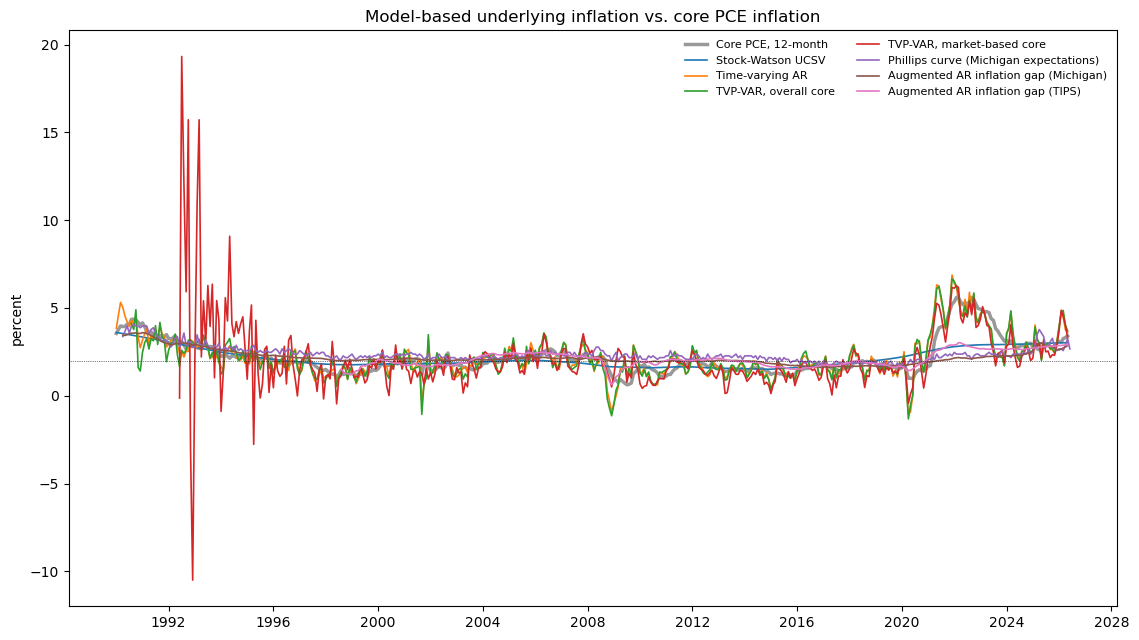

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))
plot_from = pd.Period("1990-01", freq="M")
actual = mdf["yoy_core"].loc[plot_from:]
ax.plot(actual.index.to_timestamp(), actual.values,
        color="0.6", lw=2.5, label="Core PCE, 12-month")
for name, s in ROWS[5:]:
    ss = s.loc[plot_from:]
    ax.plot(ss.index.to_timestamp(), ss.values, lw=1.2, label=name)
ax.axhline(2.0, color="k", lw=0.5, ls=":")
ax.set_ylabel("percent")
ax.set_title("Model-based underlying inflation vs. core PCE inflation")
ax.legend(fontsize=8, ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Sanity checks

The 2010–2019 averages of the published series are checked against their well-known
values (core PCE ≈ 1.6), and each model's 2010–2019 average is compared with the Dallas
trimmed mean, which the note's model estimates track within a few tenths. Sampler
diagnostics (explosive-draw shares, MH acceptance) are printed alongside.

In [12]:
# Sanity checks against well-known values and the Fed note's reported ranges
# (their 2010-2019 column sits roughly in the 1.5-1.7% range for most rows).
avg_col = col_labels[1]  # 2010-2019
benchmarks = {
    "Core PCE (12-month)": 1.6,
    "Market-based core PCE (12-month)": 1.4,
    "Trimmed mean PCE (FRB Dallas)": 1.7,
    "Median PCE (FRB Cleveland)": 1.9,
}
print(f"--- checks on the {avg_col} column ---")
for row, target in benchmarks.items():
    val = table.loc[row, avg_col]
    flag = "PASS" if abs(val - target) < 0.25 else "WARN"
    print(f"{flag}: {row}: {val:.2f} (expected ~{target:.1f})")

anchor = table.loc["Trimmed mean PCE (FRB Dallas)", avg_col]
for row in table.index[5:]:
    val = table.loc[row, avg_col]
    if np.isnan(val):
        print(f"  --  {row}: no 2010-2019 history")
        continue
    if row.startswith("Phillips curve"):
        # the note's PC-based measure also ran ~2.0 over 2010-2019 (Michigan
        # expectations sat well above realized inflation)
        flag = "PASS" if abs(val - 2.0) < 0.3 else "WARN"
        print(f"{flag}: {row}: {val:.2f} (expected ~2.0, per the note)")
        continue
    flag = "PASS" if abs(val - anchor) < 0.4 else "WARN"
    print(f"{flag}: {row}: {val:.2f} (within 0.4 of trimmed mean {anchor:.2f})")

print("\n--- sampler diagnostics ---")
print(f"TV-AR unstable-draw share:        {res_tvar['reject_rate']:.2%}")
print(f"TVP-VAR core explosive share:     {res_var_core['reject_rate']:.2%}")
print(f"TVP-VAR mb explosive share:       {res_var_mb['reject_rate']:.2%}")
print(f"AugAR Michigan psi MH acceptance: {res_aar_mich['mh_accept']:.0%} "
      f"(rho={res_aar_mich['rho']:.2f}, psi={res_aar_mich['psi']:.2f})")
print(f"AugAR TIPS psi MH acceptance:     {res_aar_tips['mh_accept']:.0%} "
      f"(rho={res_aar_tips['rho']:.2f}, psi={res_aar_tips['psi']:.2f})")

--- checks on the 2010-2019 column ---
PASS: Core PCE (12-month): 1.59 (expected ~1.6)
PASS: Market-based core PCE (12-month): 1.33 (expected ~1.4)
PASS: Trimmed mean PCE (FRB Dallas): 1.64 (expected ~1.7)
PASS: Median PCE (FRB Cleveland): 2.02 (expected ~1.9)
PASS: Stock-Watson UCSV: 1.70 (within 0.4 of trimmed mean 1.64)
PASS: Time-varying AR: 1.57 (within 0.4 of trimmed mean 1.64)
PASS: TVP-VAR, overall core: 1.57 (within 0.4 of trimmed mean 1.64)
PASS: TVP-VAR, market-based core: 1.32 (within 0.4 of trimmed mean 1.64)
PASS: Phillips curve (Michigan expectations): 2.06 (expected ~2.0, per the note)
PASS: Augmented AR inflation gap (Michigan): 1.83 (within 0.4 of trimmed mean 1.64)
PASS: Augmented AR inflation gap (TIPS): 1.85 (within 0.4 of trimmed mean 1.64)

--- sampler diagnostics ---
TV-AR unstable-draw share:        0.00%
TVP-VAR core explosive share:     0.00%
TVP-VAR mb explosive share:       7.00%
AugAR Michigan psi MH acceptance: 44% (rho=0.50, psi=0.19)
AugAR TIPS psi MH a